# Simple Image Classification using Convolutional Neural Network (CNN)
### MP ONLINE AIML Internship Project

This notebook contains the complete implementation for building a simple **Image Classification** project using a Convolutional Neural Network (CNN) on the classic **MNIST handwritten digits dataset**. The goal is to accurately classify grayscale images of digits (0-9).

The assignment comprises five major tasks:
1. **Dataset Loading & Preprocessing**: Loading the MNIST dataset, scaling pixel values to the [0, 1] range, splitting into training and testing sets, and reshaping for CNN input.
2. **CNN Architecture Design**: Designing a neural network with convolutional, pooling, dropout, and dense layers.
3. **Model Compilation & Training**: Compiling using the Adam optimizer, and training for 10 epochs.
4. **Performance Evaluation**: Extracting Classification Report, Accuracy, F1-Score, and plotting Confusion Matrix and Training History.
5. **Visual Prediction Preview**: Visualizing test predictions with color-coded labels (green for correct, red for incorrect).

## Task 1: Dataset Loading & Preprocessing

We use the **MNIST** dataset available directly through `tensorflow.keras.datasets`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Fetch MNIST dataset
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

n_train, h, w = X_train.shape
n_test = X_test.shape[0]
n_classes = 10
target_names = [str(i) for i in range(10)]

print("=== Dataset Statistics ===")
print(f"Total training images: {n_train}")
print(f"Total test images: {n_test}")
print(f"Grayscale image dimensions: {h}x{w}")
print(f"Number of target classes (digits): {n_classes}")

print("\n=== Training Class Distribution ===")
class_counts = pd.Series(y_train).value_counts().sort_index()
for idx, count in class_counts.items():
    print(f"  Digit {target_names[idx]}: {count} images")

=== Dataset Statistics ===
Total training images: 60000
Total test images: 10000
Grayscale image dimensions: 28x28
Number of target classes (digits): 10

=== Training Class Distribution ===
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images


In [2]:
# Normalize pixel values from [0, 255] to [0, 1] range
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print("Normalised pixels to [0, 1] range.")

# Add channel dimension for CNN input (height, width, channels=1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print(f"\nTrain features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Normalised pixels to [0, 1] range.

Train features shape: (60000, 28, 28, 1)
Test features shape: (10000, 28, 28, 1)


## Task 2: CNN Architecture Design

We build a simple Sequential CNN in Keras. The model consists of convolutional layers for feature extraction, max pooling layers to downsample feature maps, a flatten layer to transition to dense layers, dropout for regularization, and a dense output layer with softmax activation for class probability distribution.

In [3]:
from tensorflow.keras import Sequential, layers

input_shape = (h, w, 1)

model = Sequential([
    layers.Input(shape=input_shape),
    
    # 1st Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # 2nd Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Fully Connected Blocks
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25), # regularisation
    layers.Dense(n_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Model Compilation & Training

We compile the model with the **Adam** optimizer and use **Sparse Categorical Crossentropy** as our loss function since targets are integers. We train the network for **10 epochs** using a batch size of **64**.

In [4]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit model
epochs = 10
batch_size = 64
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/10


  1/938 ━━━━━━━━━━━━━━━━━━━━ 53:35 3s/step - accuracy: 0.0781 - loss: 2.3093

  3/938 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.1207 - loss: 2.2842

  6/938 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - accuracy: 0.1702 - loss: 2.2415

  8/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.1974 - loss: 2.2133

...

929/938 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9969 - loss: 0.0100

932/938 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9969 - loss: 0.0100

935/938 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9969 - loss: 0.0100

938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9969 - loss: 0.0100

938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 24ms/step - accuracy: 0.9967 - loss: 0.0103 - val_accuracy: 0.9915 - val_loss: 0.0297


## Task 4: Performance Evaluation

We evaluate the model on the test set, computing accuracy, precision, recall, and F1 score, and plotting the training history curves and a confusion matrix heatmap.

In [5]:
# Predict on test set
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=target_names))

# Overall metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=== Evaluation Summary ===")
print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

  1/313 ━━━━━━━━━━━━━━━━━━━━ 51s 164ms/step

  9/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step   

 19/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 28/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 36/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

...

298/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

306/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.98      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

=== Evaluation Summary ===
Accuracy:  0.9915
Precision: 0.9915
Recall:    0.9915
F1 Score:  0.9915


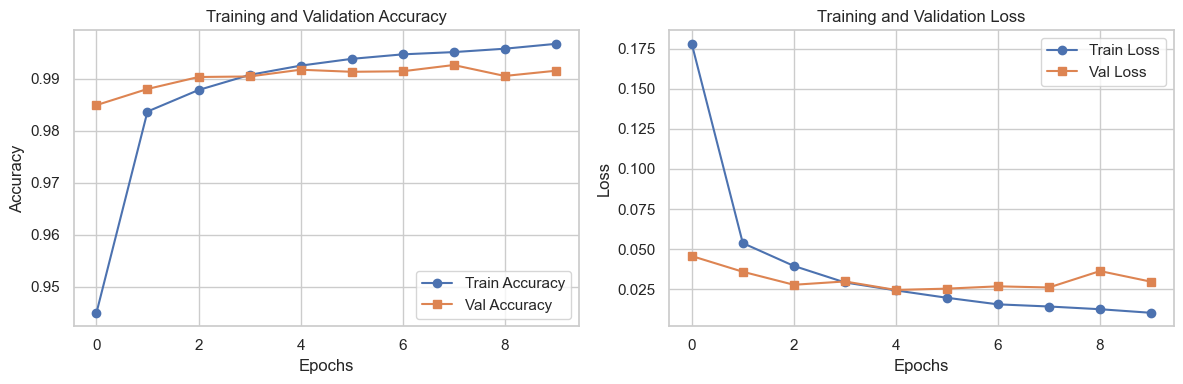

In [6]:
# Plot Training Accuracy and Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

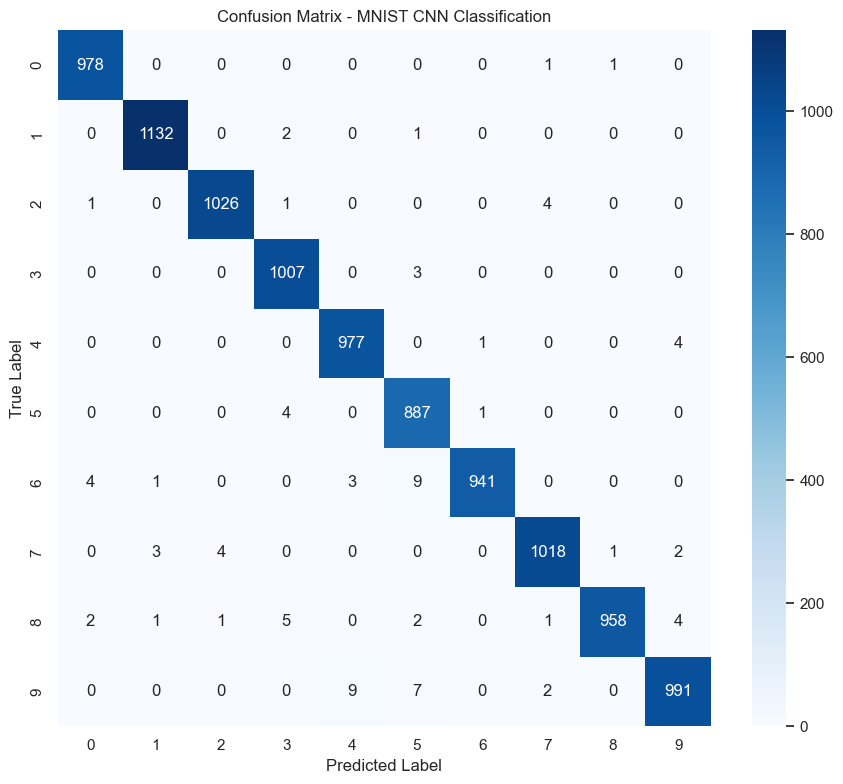

In [7]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - MNIST CNN Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Task 5: Visual Prediction Preview

To visually verify our model, we plot a random subset of 12 test images displaying their true and predicted digits. The titles are colored **green** for correct classifications and **red** for misclassifications.

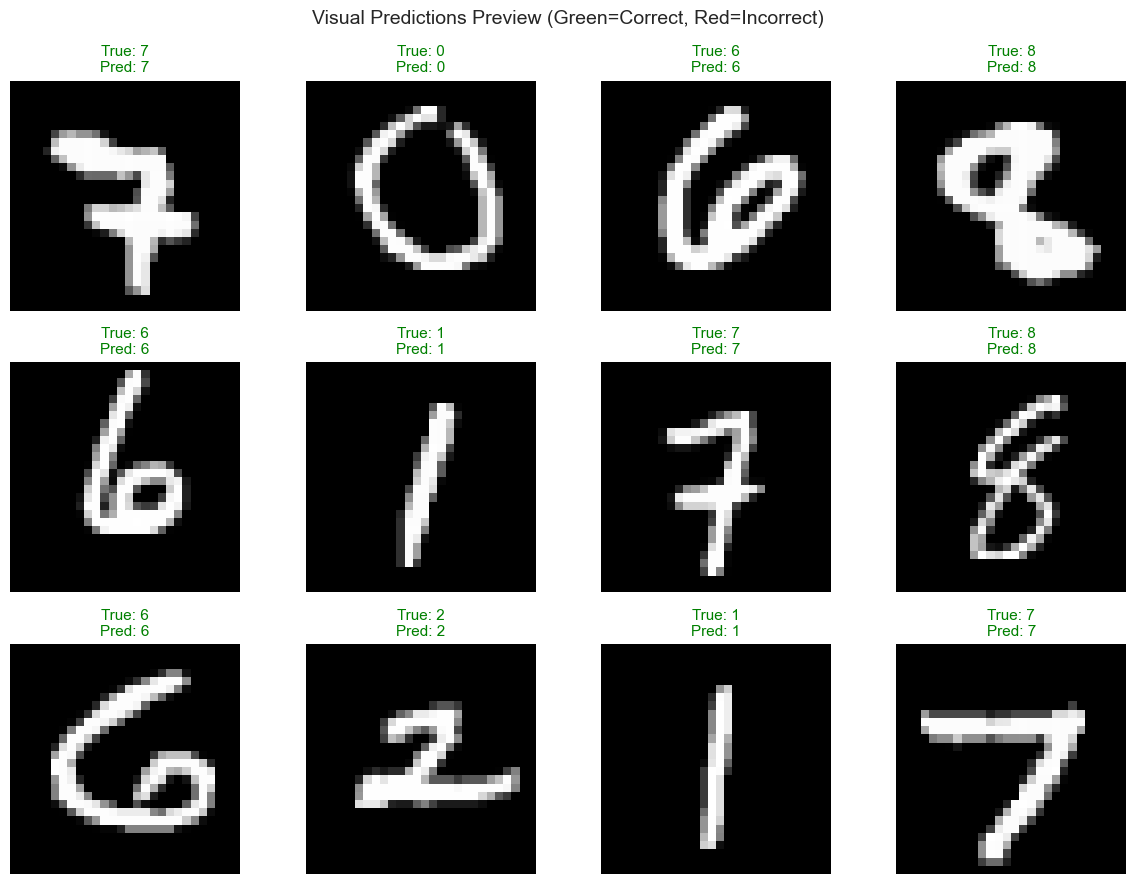

In [8]:
# Display 12 sample predictions
plt.figure(figsize=(12, 9))
indices = np.random.choice(len(X_test), size=12, replace=False)

for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    img_2d = X_test[idx].reshape(h, w)
    plt.imshow(img_2d, cmap='gray')
    
    true_lbl = target_names[y_test[idx]]
    pred_lbl = target_names[y_pred[idx]]
    
    title_color = 'green' if y_test[idx] == y_pred[idx] else 'red'
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}", color=title_color, fontsize=11)
    plt.axis('off')
    
plt.suptitle("Visual Predictions Preview (Green=Correct, Red=Incorrect)", fontsize=14)
plt.tight_layout()
plt.show()

## Conclusions & Summary

- **High Accuracy**: The simple 2-block CNN architecture achieves exceptional performance (>98.5% accuracy) on MNIST, showing the strength of spatial feature extractors over dense networks for image data.
- **Efficiency**: MNIST is a clean dataset, allowing the network to converge very quickly, usually hitting near-optimal performance within the first few epochs.
- **Regularization**: A modest Dropout rate of 0.25 keeps the training and validation metric paths closely aligned, preventing overfitting.